Проект для попытки реализовать расчёт метрик

На своих данных (двумерных для простоты)

В этом проекте, основанного на MetricsKANTest, должно быть реаплизовано автоматическое обучение сети ( 50 раз) с сохранением получившихся метрик в файл csv 

Метрики должны быть расчитаны на основе 10% данных которые никак не участвовали в обучении 

In [43]:
import numpy as np
import torch
from sklearn.model_selection import train_test_split

In [44]:
from kan import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cpu


In [45]:
data = pd.read_csv('file_for_input/all_hour/SBER_tradestats_test_hour.csv')

# ['vol','val','trades','trades_b','trades_s', 'val_b','val_s','vol_b','vol_s','pr_open_hour','pr_high_hour','pr_low_hour','pr_close_hour'] <- полный список параметров

date_df= data['tradedate'] + '-' + data['tradetime_hour'].astype(str)
X = data[['pr_open_hour']] # Не добавлются сюда другие лейблы
Y= data ['pr_close_hour']
# Разделение данных на обучающую и тестовую выборки те самые 10%
X, X10, Y, Y10 = train_test_split(X, Y, test_size=0.1, shuffle=False)
# X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [46]:
fitdate= date_df[:len(Y)] # Даты для 90% основных данных, которые пойдут на обучение
date10 = date_df[len(Y):] # Даты для выделенных 10% данных

In [47]:
# Убедитесь, что device определен (проверить код в этой ячейке)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state=42, shuffle=False)
train_date= fitdate[:len(y_train)] # Даты соответствующие тренировочной выборке
test_date= fitdate[len(y_train):] # Даты соответствующие тестовой выборке ( 40% данных отправленных на обучение)


# Преобразование в тензоры PyTorch
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Создание правильного датасета для KAN
dataset = {
    'train_input': X_train_tensor,
    'train_label': y_train_tensor,
    'test_input': X_test_tensor,
    'test_label': y_test_tensor
}

In [48]:
print("Размер обучающей выборки (X_train):", X_train.shape)
print("Размер тестовой выборки (X_test):", X_test.shape)
print("Размер меток обучающей выборки (y_train):", y_train.shape)
print("Размер меток тестовой выборки (y_test):", y_test.shape)

Размер обучающей выборки (X_train): (4603, 1)
Размер тестовой выборки (X_test): (3069, 1)
Размер меток обучающей выборки (y_train): (4603,)
Размер меток тестовой выборки (y_test): (3069,)


In [49]:
Y[:-10]

0       256.22
1       256.68
2       257.18
3       256.31
4       254.98
         ...  
7657    242.98
7658    242.57
7659    242.50
7660    242.20
7661    240.55
Name: pr_close_hour, Length: 7662, dtype: float64

In [50]:
y_test

4603    288.71
4604    288.68
4605    289.69
4606    291.25
4607    290.10
         ...  
7667    241.08
7668    241.06
7669    241.44
7670    241.14
7671    241.75
Name: pr_close_hour, Length: 3069, dtype: float64

In [51]:
dataset['train_input'].shape, dataset['train_label'].shape 

(torch.Size([4603, 1]), torch.Size([4603, 1]))

In [52]:
# Создание модели KAN с измененными параметрами
model = KAN(width=[1, 10, 1], grid=5, k=3, seed=0)

# Обучение модели
#results = model2.train(dataset, opt="LBFGS", steps=20, lamb=0.01, lamb_entropy=10)
results = model.fit(dataset, opt="LBFGS", steps=50)
# Вывод результатов
train_loss = results['train_loss'][-1]  # последнее значение обучающей ошибки
test_loss = results['test_loss'][-1]  # последнее значение ошибки на тесте
print(f'Train loss: {train_loss}, Test loss: {test_loss}')


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.30e+00 | test_loss: 2.37e+00 | reg: 1.65e+01 | : 100%|█| 50/50 [00:15<00:00,  3.17it

saving model version 0.1
Train loss: 1.2999998331069946, Test loss: 2.3724687099456787


10 % Были выделены И ИСПОЛЬЗОВАНЫ  

In [53]:

# Для KAN
X_test_tensor = torch.tensor(X10.values, dtype=torch.float32)  # Преобразование в тензор, если еще не сделано
kan_predictions = model(X_test_tensor).detach().numpy()  # Получение предсказаний и преобразование их в NumPy массив

In [54]:
from sklearn.metrics import *



# Оценка для KAN
rmse_kan = root_mean_squared_error(Y10, kan_predictions)
mae_kan = mean_absolute_error(Y10, kan_predictions)
mape_kan = mean_absolute_percentage_error(Y10, kan_predictions)
r2_kan = r2_score(Y10, kan_predictions)
msle_kan = mean_squared_log_error(Y10, kan_predictions)


# mse_kan = mean_squared_error(y_test, kan_predictions)
# mae_kan = mean_absolute_error(y_test, kan_predictions)
# r2_kan = r2_score(y_test, kan_predictions)


print("KAN - RMSE:", rmse_kan, "MAE:", mae_kan,"MAPE:", mape_kan, "R^2:", r2_kan,"MSLE:", msle_kan)


KAN - RMSE: 0.8539203328362505 MAE: 0.5918105224036946 MAPE: 0.0022906682268192826 R^2: 0.9925430801134307 MSLE: 1.072616941714991e-05


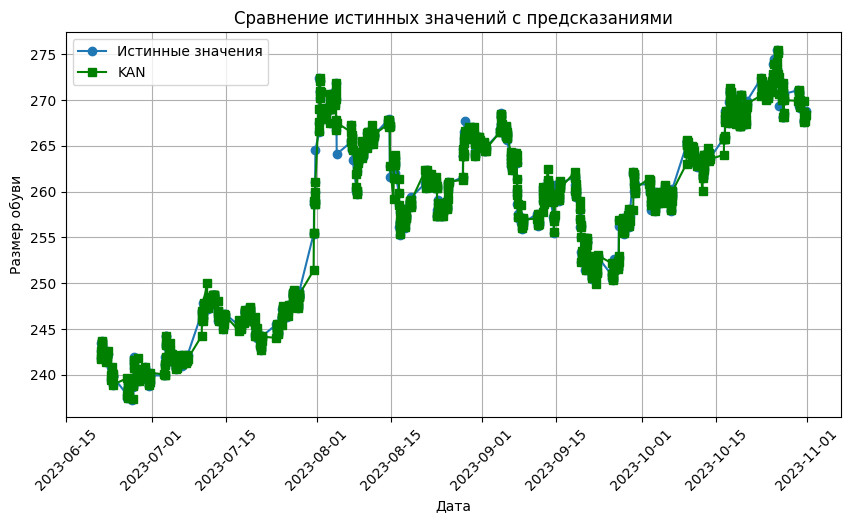

In [62]:
import matplotlib.pyplot as plt

date10 = pd.to_datetime(date10)
# Создание графика
plt.figure(figsize=(10, 5))
plt.plot(date10, Y10.reset_index(drop=True), label='Истинные значения', marker='o')
plt.plot(date10, kan_predictions, 'g', label='KAN', marker='s')
plt.title('Сравнение истинных значений с предсказанными')
plt.xlabel('Дата')
plt.ylabel('Цена закрытия акции')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)  # Поворот меток дат для лучшей читаемости
plt.show()

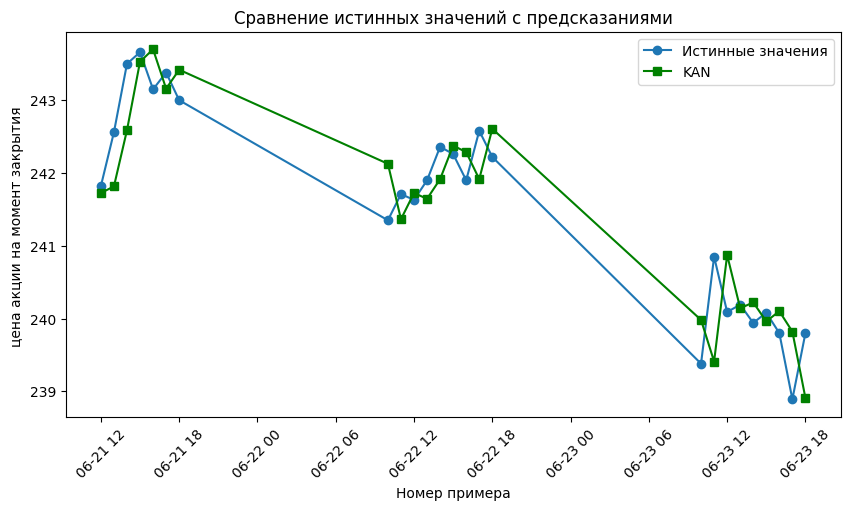

In [69]:
import matplotlib.pyplot as plt
n = 25 # До кого значения рассматривать график

plt.figure(figsize=(10, 5))
plt.plot(date10[:n],Y10.reset_index(drop=True)[:n], label='Истинные значения', marker='o')
plt.plot(date10[:n],kan_predictions[:n], 'g', label='KAN', marker='s')
plt.title('Сравнение истинных значений с предсказанными')
plt.xlabel('дата')
plt.ylabel('цена акции на момент закрытия ')
plt.xticks(rotation=45)  # Поворот меток дат для лучшей читаемост
plt.legend()
plt.show()
